In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('datan1.zip')
df.head(10)

,date,number_of_strikes,center_point_geom
0,2018-01-03,194,POINT(-75 27)
1,2018-01-03,41,POINT(-78.4 29)
2,2018-01-03,33,POINT(-73.9 27)
3,2018-01-03,38,POINT(-73.8 27)
4,2018-01-03,92,POINT(-79 28)
5,2018-01-03,119,POINT(-78 28)
6,2018-01-03,35,POINT(-79.3 28)
7,2018-01-03,60,POINT(-79.1 28)
8,2018-01-03,41,POINT(-78.7 28)
9,2018-01-03,119,POINT(-78.6 28)


In [27]:
df.shape

(3401012, 3)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3401012 entries, 0 to 3401011
Data columns (total 3 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   date               object
 1   number_of_strikes  int64 
 2   center_point_geom  object
dtypes: int64(1), object(2)
memory usage: 77.8+ MB


In [29]:
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3401012 entries, 0 to 3401011
Data columns (total 3 columns):
 #   Column             Dtype         
---  ------             -----         
 0   date               datetime64[ns]
 1   number_of_strikes  int64         
 2   center_point_geom  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 77.8+ MB


In [30]:
dfg=df.groupby(['date']).sum()
df_sorted=dfg.sort_values(by='number_of_strikes',ascending=False)
df_sorted.head(10)

,number_of_strikes
date,
2018-08-29,1070457
2018-08-17,969774
2018-08-28,917199
2018-08-27,824589
2018-08-30,802170
2018-08-19,786225
2018-08-18,741180
2018-08-16,734475
2018-08-31,723624


In [31]:
df['month']=df['date'].dt.month
df['month_text']=df['date'].dt.month_name()
df.head(10)

,date,number_of_strikes,center_point_geom,month,month_text
0,2018-01-03,194,POINT(-75 27),1,January
1,2018-01-03,41,POINT(-78.4 29),1,January
2,2018-01-03,33,POINT(-73.9 27),1,January
3,2018-01-03,38,POINT(-73.8 27),1,January
4,2018-01-03,92,POINT(-79 28),1,January
5,2018-01-03,119,POINT(-78 28),1,January
6,2018-01-03,35,POINT(-79.3 28),1,January
7,2018-01-03,60,POINT(-79.1 28),1,January
8,2018-01-03,41,POINT(-78.7 28),1,January
9,2018-01-03,119,POINT(-78.6 28),1,January


In [32]:
df_month=df.groupby(['month','month_text']).sum().sort_values('number_of_strikes',ascending=False)
df_month.head(12)

,,number_of_strikes
month,month_text,
8,August,15525255
7,July,8320400
6,June,6445083
5,May,4166726
9,September,3018336
2,February,2071315
4,April,1524339
10,October,1093962
1,January,860045


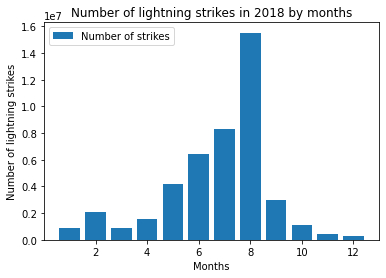

In [41]:
df_month = df_month.reset_index()
plt.bar(x=df_month["month"],height=df_month["number_of_strikes"],label="Number of strikes",)
plt.xlabel("Months")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes in 2018 by months")
plt.legend()
plt.show()